# Numerical Appendix

**Model.** A risk-neutral agent under limited liability exerts hidden effort $e_t \in [0,1]$ in periods $t \in \{1,2\}$ and spends a budget $b_t$ that lowers the cost of effort,
$$c(e,b) = \frac{e^2}{(1+b)^n}.$$
Output is binary with $\Pr(y_t = 1 \mid e_t) = e_t$. The total budget $B = 1$ is split across periods, so $b_2(y_1) \le 1 - b_1$. Baseline $n = \tfrac12$.

## §0 Setup (parameters, primitives, helper functions)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import warnings
from scipy.optimize import fsolve, minimize, minimize_scalar, brentq

sns.set_theme(style='whitegrid', font_scale=1.15)
COLORS = {'fb': '#2166ac', 'sb': '#f4a582', 'p': '#4daf4a',
          'a':  '#e41a1c', 'sp': 'navy'}
plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

warnings.filterwarnings('ignore', category=RuntimeWarning)

n = 0.5
B_GRID = np.linspace(0, 1, 501)

The helpers below implement the following objects:

- **Cost.** $c(e,b) = \dfrac{e^2}{(1+b)^n}$.
- **Second-period effort from IC.** $e_2(y_1) = \dfrac{(2-b_1)^n}{2}\, t_2(y_1, 1)$.
- **First-period effort from IC.** $e_1 = \dfrac{(1+b_1)^n}{2}\!\left[t_1(1) + \dfrac{(2-b_1)^n}{4}\bigl(t_2(1,1)^2 - t_2(0,1)^2\bigr)\right]$ with $t_1(0) = 0$.
- **Principal profit.** $\Pi = e_1(1 - t_1) + e_1\, e_2(1)(1 - t_2(1,1)) + (1-e_1)\, e_2(0)(1 - t_2(0,1))$.
- **Agent rent.** $U = \mathbb{E}[\text{transfers}] - \mathbb{E}[\text{cost}]$.

In [2]:
def c(e, b):
    return e**2 / (1 + b)**n

def e_from_t2(t2, b1):
    return (2 - b1)**n / 2 * t2

def e_from_t1(t1, t21, t20, b1):
    return ((1 + b1)**n / 2) * (t1 + (2 - b1)**n / 4 * (t21**2 - t20**2))

def principal_profit(t1, t21, t20, b1):
    e1  = e_from_t1(t1, t21, t20, b1)
    e21 = e_from_t2(t21, b1)
    e20 = e_from_t2(t20, b1)
    if not (0 <= e1 <= 1 and 0 <= e21 <= 1 and 0 <= e20 <= 1):
        return -np.inf
    return e1 * (1 - t1) + e1 * e21 * (1 - t21) + (1 - e1) * e20 * (1 - t20)

def agent_rent(t1, t21, t20, b1):
    e1  = e_from_t1(t1, t21, t20, b1)
    e21 = e_from_t2(t21, b1)
    e20 = e_from_t2(t20, b1)
    return (e1 * (t1 + e21 * t21 - c(e21, 1 - b1))
            + (1 - e1) * (e20 * t20 - c(e20, 1 - b1))
            - c(e1, b1))

---
# 4 Optimal Contracting

## §4.1.1 First-best

The principal chooses $(e, b)$ jointly:
$$\max_{e,b}\ e - \frac{e^2}{(1+b)^n}.$$
The $[e]$-FOC gives $e = \frac{(1+b)^n}{2}$. Substitution yields an objective $\frac{(1+b)^n}{4}$, strictly increasing in $b$, so $b_S^{FB} = 1$:
$$\boxed{\;b_S^{FB}=1,\qquad e_S^{FB}=\tfrac{\sqrt{2}}{2}\approx 0.707, \qquad \Pi_S^{FB}\approx 0.354.\;}$$

In [3]:
b_S_FB  = 1.0
e_S_FB  = (1 + b_S_FB)**n / 2
pi_S_FB = e_S_FB - c(e_S_FB, b_S_FB)
A_S_FB  = 0.0

print('--- Static First-Best ---')
print(f'  b_S^FB  = {b_S_FB:.4f}')
print(f'  e_S^FB  = {e_S_FB:.4f}')
print(f'  Pi_S^FB = {pi_S_FB:.5f}')
print(f'  A_S^FB  = {A_S_FB:.4f}')

--- Static First-Best ---
  b_S^FB  = 1.0000
  e_S^FB  = 0.7071
  Pi_S^FB = 0.35355
  A_S^FB  = 0.0000


## §4.1.2 Principal controls spending, effort unobservable

Effort is hidden, principal chooses $b$. The agent's IC pins down $t = \frac{2e}{(1+b)^n}$, so the principal solves
$$\max_{e,b}\ e\!\left(1 - \frac{2e}{(1+b)^n}\right),$$
yielding $e = \frac{(1+b)^n}{4}$ and an objective of $\frac{(1+b)^n}{8}$. Thus:
$$\boxed{\;t_S^P=\tfrac12,\quad b_S^P = 1, \quad e_S^P=\tfrac{2^n}{4}\approx 0.354,\quad \Pi_S^P\approx 0.177,\quad A_S^P\approx 0.088.\;}$$

In [4]:
b_S_P  = 1.0
e_S_P  = (1 + b_S_P)**n / 4
t_S_P  = 0.5
pi_S_P = e_S_P * (1 - 2*e_S_P/(1+b_S_P)**n)
A_S_P  = e_S_P * t_S_P - c(e_S_P, b_S_P)

print('--- Static Principal controls spending ---')
print(f'  b_S^P  = {b_S_P:.4f}')
print(f'  e_S^P  = {e_S_P:.4f}')
print(f'  t_S^P  = {t_S_P:.4f}')
print(f'  Pi_S^P = {pi_S_P:.5f}')
print(f'  A_S^P  = {A_S_P:.4f}')

--- Static Principal controls spending ---
  b_S^P  = 1.0000
  e_S^P  = 0.3536
  t_S^P  = 0.5000
  Pi_S^P = 0.17678
  A_S^P  = 0.0884


## §4.1.3 Agent controls spending, both effort and spending unobservable

The agent's joint IC has $e = \frac{(1+b)^n}{2}\, t$ and the objective is increasing in $b$, so $b_S^{SB} = 1$:
$$\boxed{\;t_S^{SB}=\tfrac12,\quad b_S^{SB}=1,\quad e_S^{SB}\approx 0.354,\quad \Pi_S^{SB}\approx 0.177,\quad A_S^{SB}\approx 0.088 .\;}$$

In [5]:
b_S_SB  = 1.0
t_S_SB  = 0.5
e_S_SB  = t_S_SB * (1 + b_S_SB)**n / 2
pi_S_SB = e_S_SB * (1 - t_S_SB)
A_S_SB  = e_S_SB * t_S_SB - c(e_S_SB, b_S_SB)

print('--- Static, both effort and spending unobservable ---')
print(f'  t_S^SB  = {t_S_SB:.4f}')
print(f'  e_S^SB  = {e_S_SB:.4f}')
print(f'  b_S^SB  = {b_S_SB:.4f}')
print(f'  Pi_S^SB = {pi_S_SB:.5f}')
print(f'  A_S^SB  = {A_S_SB:.4f}')

--- Static, both effort and spending unobservable ---
  t_S^SB  = 0.5000
  e_S^SB  = 0.3536
  b_S^SB  = 1.0000
  Pi_S^SB = 0.17678
  A_S^SB  = 0.0884


## §A.1 Agent controls spending, spending observable and effort unobservable

This case appears only in the proof of Proposition 1, not in the body.

The principal posts a transfer schedule $t(b)$. The agent picks $b$ to maximize $EU(b) = \frac{t^2(b)(1+b)^n}{4}$, given the effort FOC $e = \frac{t(b)(1+b)^n}{2}$. The principal's problem yields $t^*(b) = \tfrac12$ for any $b$, so the agent picks $b = 1$:
$$\boxed{\;t_S^b=\tfrac12,\quad b_S^b=1,\quad e_S^b\approx 0.354,\quad \Pi_S^b\approx 0.177,\quad A_S^b\approx 0.088.\;}$$

In [6]:
b_S_b  = 1.0
t_S_b  = 0.5
e_S_b  = t_S_b * (1 + b_S_b)**n / 2
pi_S_b = e_S_b * (1 - t_S_b)
A_S_b  = e_S_b * t_S_b - c(e_S_b, b_S_b)

print('--- Static, b observable / e unobservable ---')
print(f'  t_S^b  = {t_S_b:.4f}')
print(f'  e_S^b  = {e_S_b:.4f}')
print(f'  b_S^b  = {b_S_b:.4f}')
print(f'  Pi_S^b = {pi_S_b:.5f}')
print(f'  A_S^b  = {A_S_b:.4f}')

--- Static, b observable / e unobservable ---
  t_S^b  = 0.5000
  e_S^b  = 0.3536
  b_S^b  = 1.0000
  Pi_S^b = 0.17678
  A_S^b  = 0.0884


In [7]:
static_df = pd.DataFrame({
    'FB':           [b_S_FB,  e_S_FB,  np.nan,  pi_S_FB, A_S_FB],
    'P controls':   [b_S_P,   e_S_P,   t_S_P,   pi_S_P,  A_S_P],
    'A controls, b observable': [b_S_b, e_S_b, t_S_b, pi_S_b, A_S_b],
    'A controls, both hidden':  [b_S_SB, e_S_SB, t_S_SB, pi_S_SB, A_S_SB],
}, index=['b', 'e', 't', 'Profit', 'Rent']).round(4)

print(static_df.to_string())

            FB  P controls  A controls, b observable  A controls, both hidden
b       1.0000      1.0000                    1.0000                   1.0000
e       0.7071      0.3536                    0.3536                   0.3536
t          NaN      0.5000                    0.5000                   0.5000
Profit  0.3536      0.1768                    0.1768                   0.1768
Rent    0.0000      0.0884                    0.0884                   0.0884


---

## §4.2 Dynamic first-best

The principal chooses $(e_1, e_2(\cdot), b_1)$:
$$\max\ e_1\!\left(1 + e_2(1) - \frac{e_2(1)^2}{(2-b_1)^n}\right) + (1-e_1)\!\left(e_2(0) - \frac{e_2(0)^2}{(2-b_1)^n}\right) - \frac{e_1^2}{(1+b_1)^n}.$$

The $[e_2]$-FOCs give $e_2^{FB}(y_1) = \frac{(2-b_1)^n}{2}$ for each $y_1$. Substituting:
$$\Pi(b_1, e_1) = e_1 + \frac{(2-b_1)^n}{4} - \frac{e_1^2}{(1+b_1)^n}.$$

The $[e_1]$-FOC gives $e_1^{FB} = \frac{(1+b_1)^n}{2}$. Substituting:
$$\Pi(b_1) = \frac{(1+b_1)^n}{4} + \frac{(2-b_1)^n}{4}.$$

The $[b_1]$-FOC is $$\frac{n}{4}\bigl[(1+b_1)^{n-1} - (2-b_1)^{n-1}\bigr] = 0,$$ giving $b_1^{FB} = \tfrac12$. At this point $e_1^{FB} = e_2^{FB}(\cdot) = \frac{(3/2)^n}{2}$. With $n = \tfrac12$:
$$\boxed{\;b_{1D}^{FB}=\tfrac12,\quad e_{1D}^{FB} = e_{2D}^{FB}(\cdot) \approx 0.612,\quad \Pi_{1D}^{FB}\approx 0.612.\;}$$

In [8]:
b_FB  = 0.5
e_FB  = (1 + b_FB)**n / 2
pi_FB = 2 * (e_FB - e_FB**2 / (1 + b_FB)**n)

print('--- Dynamic First-Best ---')
print(f'  b_1^FB = {b_FB:.4f}')
print(f'  e^FB   = {e_FB:.4f}')
print(f'  Profit = {pi_FB:.4f}')
print(f'  Rent   = 0')

--- Dynamic First-Best ---
  b_1^FB = 0.5000
  e^FB   = 0.6124
  Profit = 0.6124
  Rent   = 0


## §4.4 Agent controls spending

The agent picks effort and $b_1$. The effort ICs give the closed forms
$$e_2(y_1) = \frac{(2-b_1)^n}{2}\, t_2(y_1,1),\qquad
e_1 = \frac{(1+b_1)^n}{2}\!\left[t_1(1) + \frac{(2-b_1)^n}{4}\bigl(t_2(1,1)^2 - t_2(0,1)^2\bigr)\right].$$

The agent additionally picks $b_1$ to maximize his value function $V(b_1)$ given the contract; the FOC is
$$\frac{dV}{db_1} = \frac{n\, e_1^2}{(1+b_1)^{n+1}} - \frac{n}{(2-b_1)^{n+1}}\!\left[e_1\, e_2(1)^2 + (1-e_1)\, e_2(0)^2\right] = 0.$$

The principal's problem is
$$\max_{t_1,\, t_{21},\, t_{20}}\ \Pi(t_1, t_{21}, t_{20}) \quad \text{s.t. effort and budget ICs.}$$

Welfare is $W^A = \Pi^A + U^A$:
$$\boxed{\;b_1^A\approx 0.33,\quad e_1^A\approx 0.34,\quad e_2^A(1)\approx 0.59,\quad e_2^A(0)\approx 0.25,\quad \Pi_{1D}^A\approx 0.333,\quad W^A \approx 0.479.\;}$$

In [9]:
def agent_b1_ic(t1, t20, t21):
    eps = 1e-9
    def foc(p):
        b   = float(np.clip(p[0], eps, 1 - eps))
        l1  = (1 + b)**(n - 1);     l2  = (1 + b)**n
        i1  = (2 - b)**n / 2;       i2  = (2 - b)**(2*n) / 8
        i3  = (2 - b)**(n - 1) / 2; i4  = (2 - b)**(2*n - 1) / 4
        v1  = t1 * (t21**2 - t20**2)
        v2  = t21**4 / 2 + t20**4 / 2 - t20**2 * t21**2
        eq1 = t1**2 + i1 * v1 + i2 * v2
        eq2 = -i3 * v1 - i4 * v2
        return [l1 * eq1 + l2 * eq2 - (2 - b)**(n - 1) * t20**2]
    sol = fsolve(foc, [0.30], xtol=1e-12)
    return float(np.clip(sol[0], 0.0, 1.0))

def agent_solution(t1, t21, t20):
    b1  = agent_b1_ic(t1, t20, t21)
    e1  = e_from_t1(t1, t21, t20, b1)
    e21 = e_from_t2(t21, b1)
    e20 = e_from_t2(t20, b1)
    return b1, e1, e21, e20

def profit_agent_controls(t1, t21, t20):
    b1, e1, e21, e20 = agent_solution(t1, t21, t20)
    if not (0 <= e1 <= 1 and 0 <= e21 <= 1 and 0 <= e20 <= 1):
        return -np.inf, None
    pi = e1 * (1 - t1 + e21 * (1 - t21)) + (1 - e1) * e20 * (1 - t20)
    return pi, (b1, e1, e21, e20)

In [10]:
GRID  = np.linspace(0, 1, 21)
best_pi    = -np.inf
best_start = (0.4, 0.9, 0.4)
for t1 in GRID:
    for t21 in GRID:
        for t20 in GRID:
            pi, _ = profit_agent_controls(t1, t21, t20)
            if np.isfinite(pi) and pi > best_pi:
                best_pi, best_start = pi, (t1, t21, t20)

def neg_profit_agent(x):
    pi, _ = profit_agent_controls(*x)
    return -pi if np.isfinite(pi) else 1e6

res_A = minimize(neg_profit_agent, best_start, method='L-BFGS-B',
                 bounds=[(0, 1)]*3, options={'ftol': 1e-12, 'gtol': 1e-10})
t1_A, t21_A, t20_A = res_A.x
pi_A, vals_A = profit_agent_controls(t1_A, t21_A, t20_A)
b_A, e1_A, e21_A, e20_A = vals_A
A_A = agent_rent(t1_A, t21_A, t20_A, b_A)
W_A = pi_A + A_A

print('--- Agent controls spending ---')
print(f'  b_1^A    = {b_A:.4f}')
print(f'  e_1^A    = {e1_A:.4f}')
print(f'  e_2^A(1) = {e21_A:.4f}')
print(f'  e_2^A(0) = {e20_A:.4f}')
print(f'  t_1(1)   = {t1_A:.4f}')
print(f'  t_2(1,1) = {t21_A:.4f}')
print(f'  t_2(0,1) = {t20_A:.4f}')
print(f'  Profit   = {pi_A:.5f}')
print(f'  Rent     = {A_A:.4f}')
print(f'  Welfare  = {W_A:.5f}')

--- Agent controls spending ---
  b_1^A    = 0.3284
  e_1^A    = 0.3359
  e_2^A(1) = 0.5930
  e_2^A(0) = 0.2490
  t_1(1)   = 0.3589
  t_2(1,1) = 0.9173
  t_2(0,1) = 0.3852
  Profit   = 0.33350
  Rent     = 0.1459
  Welfare  = 0.47938


## §4.5 Principal controls spending, agent exerts unobservable effort

The principal sets $(b_1, t_1(\cdot), t_2(\cdot,\cdot))$. Substituting the effort ICs
$$t_2(y_1,1) = \frac{2\, e_2(y_1)}{(2-b_1)^n},\qquad t_1(1) - t_1(0) = \frac{2\, e_1}{(1+b_1)^n} + \frac{e_2(0)^2 - e_2(1)^2}{(2-b_1)^n},$$
with limited liability $t_1(0) = 0$ and $b_2 = 1 - b_1$, the principal's reduced-form objective is
$$\Pi = e_1\!\left(1 + e_2(1) - \frac{e_2(1)^2}{(2-b_1)^n}\right) + e_2(0) - \frac{2\, e_2(0)^2}{(2-b_1)^n} - \frac{2\, e_1^2}{(1+b_1)^n} - e_1\!\left(e_2(0) - \frac{e_2(0)^2}{(2-b_1)^n}\right).$$

The $[e_2(1)]$-FOC gives $e_2(1) = \frac{(2-b_1)^n}{2}$ in closed form. The residual $\{[e_1], [e_2(0)]\}$ system is reduced to a single equation in $e_1$ and solved at each $b_1$ via `brentq`; sweeping $b_1$ on a fine grid picks the optimal value for the principal. The transfers are then recovered from the effort ICs and the agent's rent is computed from `agent_rent`. Welfare is $W^P = \Pi^P + U^P$:
$$\boxed{\;b_1^P\approx 0.53,\;e_1^P\approx 0.34,\;e_2^P(1)\approx 0.61,\;e_2^P(0)\approx 0.24,\;\Pi_{1D}^P\approx 0.336,\;A_{1D}^P\approx 0.143,\;W^P\approx 0.479.\;}$$

In [11]:
def solve_principal_at_b(b1):
    e21 = (2 - b1)**n / 2
    def e1_resid(e1):
        e20 = (2 - b1)**n / 2 * (1 - e1) / (2 - e1)
        return 1 + (2-b1)**n/4 - 4*e1/(1+b1)**n - e20 + e20**2/(2-b1)**n
    e1 = brentq(e1_resid, 1e-6, 1 - 1e-6, xtol=1e-13)
    e20 = (2 - b1)**n / 2 * (1 - e1) / (2 - e1)
    return e1, e20, e21

def profit_principal(e1, e20, e21, b1):
    return (e1 * (1 + e21 - e21**2 / (2 - b1)**n)
            + e20 - 2 * e20**2 / (2 - b1)**n
            - 2 * e1**2 / (1 + b1)**n
            - e1 * (e20 - e20**2 / (2 - b1)**n))

e1_grid, e20_grid, e21_grid = (np.empty_like(B_GRID) for _ in range(3))
for i, b in enumerate(B_GRID):
    e1_grid[i], e20_grid[i], e21_grid[i] = solve_principal_at_b(b)
prof_grid = profit_principal(e1_grid, e20_grid, e21_grid, B_GRID)

idx_P = int(np.argmax(prof_grid))
b_P, e1_P, e20_P, e21_P = B_GRID[idx_P], e1_grid[idx_P], e20_grid[idx_P], e21_grid[idx_P]

t21_P = 2 * e21_P / (2 - b_P)**n
t20_P = 2 * e20_P / (2 - b_P)**n
t1_P  = 2 * e1_P / (1 + b_P)**n + e20_P**2/(2 - b_P)**n - e21_P**2/(2 - b_P)**n
pi_P  = prof_grid[idx_P]
A_P   = agent_rent(t1_P, t21_P, t20_P, b_P)
W_P   = pi_P + A_P

print('--- Principal controls spending ---')
print(f'  b_1^P    = {b_P:.4f}')
print(f'  e_1^P    = {e1_P:.4f}')
print(f'  e_2^P(1) = {e21_P:.4f}')
print(f'  e_2^P(0) = {e20_P:.4f}')
print(f'  t_1(1)   = {t1_P:.4f}')
print(f'  t_2(1,1) = {t21_P:.4f}')
print(f'  t_2(0,1) = {t20_P:.4f}')
print(f'  Profit   = {pi_P:.5f}')
print(f'  Rent     = {A_P:.4f}')
print(f'  Welfare  = {W_P:.5f}')

--- Principal controls spending ---
  b_1^P    = 0.5320
  e_1^P    = 0.3436
  e_2^P(1) = 0.6058
  e_2^P(0) = 0.2401
  t_1(1)   = 0.2999
  t_2(1,1) = 1.0000
  t_2(0,1) = 0.3963
  Profit   = 0.33570
  Rent     = 0.1430
  Welfare  = 0.47865


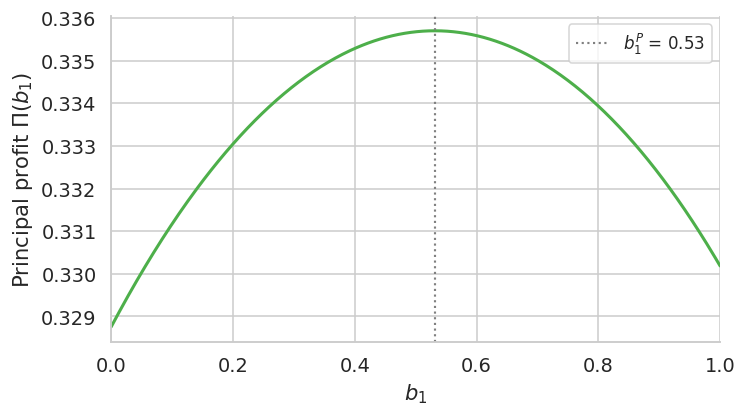

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(B_GRID, prof_grid, color=COLORS['p'], lw=2)
ax.axvline(b_P, color='gray', ls=':', lw=1.4, label=f'$b_1^P$ = {b_P:.2f}')
ax.set(xlabel='$b_1$', ylabel='Principal profit $\\Pi(b_1)$', xlim=(0, 1))
ax.legend(fontsize=11, loc='best')
plt.tight_layout(); plt.show()

Induced effort levels across $b_1$ under the principal controls spending contract, with the static second-best effort for comparison. Memory holds at every $b_1$, not only at the optimum: $e_{2D}^P(1) > e_{1D}^P > e_{2D}^P(0)$ throughout.

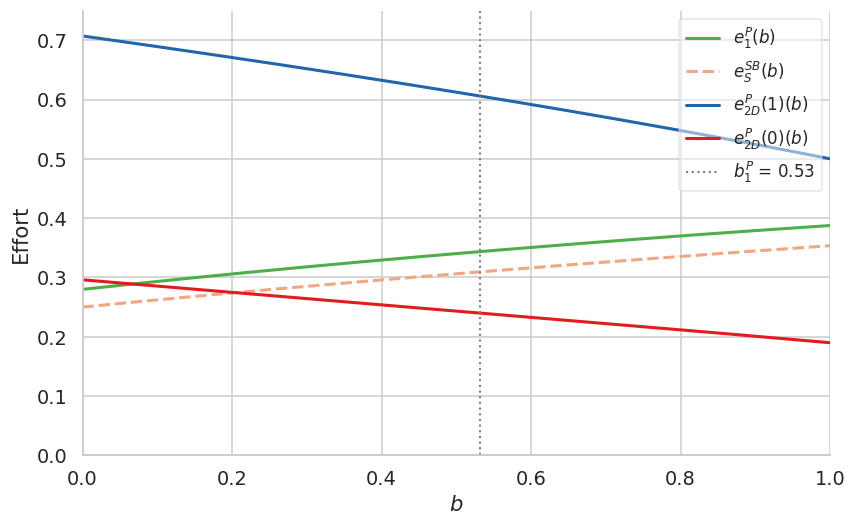

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(B_GRID, e1_grid,           label='$e_1^P(b)$',     color=COLORS['p'],  lw=2)
ax.plot(B_GRID, (1+B_GRID)**n / 4, label='$e_S^{SB}(b)$',  color=COLORS['sb'], lw=2, ls='--')
ax.plot(B_GRID, e21_grid,          label='$e_{2D}^P(1)(b)$', color=COLORS['fb'], lw=2)
ax.plot(B_GRID, e20_grid,          label='$e_{2D}^P(0)(b)$', color=COLORS['a'],  lw=2)
ax.axvline(b_P, color='gray', ls=':', lw=1.4, label=f'$b_1^P$ = {b_P:.2f}')
ax.set(xlabel='$b$', ylabel='Effort', xlim=(0, 1), ylim=(0, 0.75))
ax.legend(fontsize=11, framealpha=0.5, loc='best')
plt.tight_layout(); plt.show()

## §4.6 Discussion

### What the Agent Would Pick Under the Principal's Contract
Evaluate the agent's value function at the principal controls spending contract $(t_1^P, t_2^P(1,1), t_2^P(0,1))$ as $b_1$ varies. With second-period effort optimized over $b_1$ via the IC, the agent's expected payoff is
$$V(b_1) = e_1\, t_1(1) + e_1 \cdot \frac{e_2(1)^2}{(2-b_1)^n} + (1-e_1) \cdot \frac{e_2(0)^2}{(2-b_1)^n} - \frac{e_1^2}{(1+b_1)^n},$$
where $e_1 = e_1(b_1)$ from the agent's first-period IC and $e_2(y_1)$ from the second-period ICs at the principal controls spending transfers. Maximize numerically over $b_1$ to find the agent's preferred $b_1$ at the principal controls spending contract.

Agent's preferred b_1 under the principal's contract: 0.1780


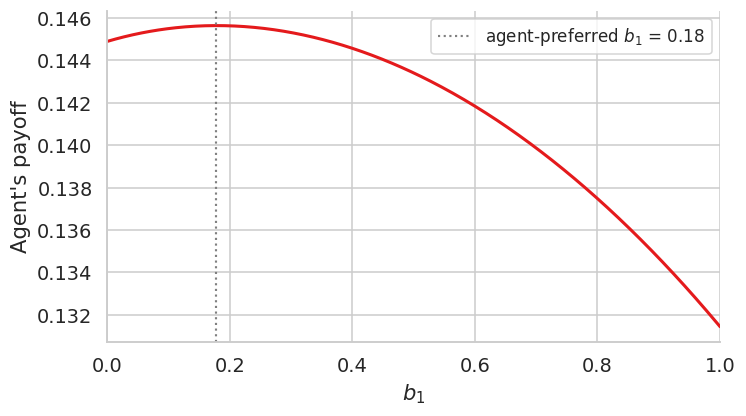

In [14]:
def agent_payoff_at_b(b1, t1, t21, t20):
    e1  = e_from_t1(t1, t21, t20, b1)
    u_y1 = lambda y, b: (e_from_t2((t21 if y else t20), b)**2) / (2 - b)**n
    return e1 * t1 - c(e1, b1) + e1 * u_y1(1, b1) + (1 - e1) * u_y1(0, b1)

agent_payoff_grid = np.array([agent_payoff_at_b(b, t1_P, t21_P, t20_P) for b in B_GRID])
b_A_at_P = B_GRID[int(np.argmax(agent_payoff_grid))]
print(f"Agent's preferred b_1 under the principal's contract: {b_A_at_P:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(B_GRID, agent_payoff_grid, color=COLORS['a'], lw=2)
ax.axvline(b_A_at_P, color='gray', ls=':', lw=1.4,
           label=fr'agent-preferred $b_1$ = {b_A_at_P:.2f}')
ax.set(xlabel='$b_1$', ylabel="Agent's payoff", xlim=(0, 1))
ax.legend(fontsize=11, loc='best')
plt.tight_layout(); plt.show()

### Effort Distortion at the Same $b_1$

The principal controls spending and agent controls spending equilibria differ along two margins: the equilibrium $b_1$ itself ($b_1^P \neq b_1^A$) and the induced effort levels at the equilibrium $b_1$. To separate these, hold $b_1$ fixed at $b_1^P$ and ask what the agent controls spending contract would look like if the agent were forced to pick $b_1 = b_1^P$.

**Setup.** In agent controls spending, the contract must satisfy the agent's $[b_1]$-IC: at the equilibrium $b_1$, the agent's first-order condition $dU/db_1 = 0$ binds. If we want the agent to pick $b_1 = b_1^P$, the contract must satisfy this condition *at* $b_1 = b_1^P$. The agent's budget IC is monotone in $t_2(0,1)$ over the region computed here, so for any $(t_1, t_2(1,1))$ a unique $t_2(0,1)$ makes the IC bind at $b_1 = b_1^P$. The principal then optimizes over the two free instruments $(t_1, t_2(1,1))$, with $t_2(0,1)$ recovered as the root of the budget IC at $b_1 = b_1^P$, solved by `brentq` over $(0,1)$.

The resulting contract $(t_1, t_2(1,1), t_2(0,1))$ differs from the principal controls spending contract at the same $b_1$ because the agent's $[b_1]$-IC adds a constraint that does not bind in principal controls spending. All three induced effort levels shift as a result, even though $b_1$ is identical across the two cases.

In [15]:
def t20_for_b1(t1, t21, b1_target):
    def f(t20):
        return agent_b1_ic(t1, t20, t21) - b1_target
    try:
        if f(0.01) * f(0.99) > 0:
            return None
        return brentq(f, 0.01, 0.99, xtol=1e-6)
    except (ValueError, RuntimeError):
        return None

def solve_agent_at_b(b1_target):
    def neg_profit_2d(x):
        t1, t21 = x
        if not (0 <= t1 <= 1 and 0 <= t21 <= 1):
            return 1e6
        t20 = t20_for_b1(t1, t21, b1_target)
        if t20 is None or not (0 <= t20 <= 1):
            return 1e6
        pi, _ = profit_agent_controls(t1, t21, t20)
        return -pi if np.isfinite(pi) else 1e6

    starts = [[0.40, 0.90], [0.30, 1.00], [0.50, 0.85],
              [0.42, 0.86], [0.35, 0.95], [0.45, 0.80]]
    best_pi, best_x = -np.inf, None
    for s in starts:
        res = minimize(neg_profit_2d, s, method='Nelder-Mead',
                       options={'xatol':1e-6, 'fatol':1e-9, 'maxiter':1000})
        if -res.fun > best_pi:
            t1, t21 = res.x
            t20 = t20_for_b1(t1, t21, b1_target)
            if t20 is not None and 0 <= t20 <= 1:
                pi, _ = profit_agent_controls(t1, t21, t20)
                if np.isfinite(pi) and pi > best_pi:
                    best_pi, best_x = pi, (t1, t20, t21)
    return best_x, best_pi

sol_x, sol_pi = solve_agent_at_b(b_P)

if sol_x is not None:
    t1_c, t20_c, t21_c = sol_x
    e1_c  = e_from_t1(t1_c, t21_c, t20_c, b_P)
    e21_c = e_from_t2(t21_c, b_P)
    e20_c = e_from_t2(t20_c, b_P)

    print(f'--- Agent controls spending Constrained at b_1 = {b_P:.4f} ---')
    print(f'  t_1(1)   = {t1_c:.4f}')
    print(f'  t_2(1,1) = {t21_c:.4f}')
    print(f'  t_2(0,1) = {t20_c:.4f}')
    print(f'  e_1      = {e1_c:.4f}')
    print(f'  e_2(1)   = {e21_c:.4f}')
    print(f'  e_2(0)   = {e20_c:.4f}')
    print(f'  Profit   = {sol_pi:.6f}')
    print()
    print(f'Recap: principal controls spending at the same b_1')
    print(f'  t_1(1)   = {t1_P:.4f}     e_1    = {e1_P:.4f}')
    print(f'  t_2(1,1) = {t21_P:.4f}    e_2(1) = {e21_P:.4f}')
    print(f'  t_2(0,1) = {t20_P:.4f}    e_2(0) = {e20_P:.4f}')
    print(f'  Profit   = {pi_P:.6f}')

--- Agent controls spending Constrained at b_1 = 0.5320 ---
  t_1(1)   = 0.4172
  t_2(1,1) = 0.8452
  t_2(0,1) = 0.3617
  e_1      = 0.3676
  e_2(1)   = 0.5120
  e_2(0)   = 0.2191
  Profit   = 0.331814

Recap: principal controls spending at the same b_1
  t_1(1)   = 0.2999     e_1    = 0.3436
  t_2(1,1) = 1.0000    e_2(1) = 0.6058
  t_2(0,1) = 0.3963    e_2(0) = 0.2401
  Profit   = 0.335699


In [16]:
order_P = pd.Series({
    'e_S^FB':       e_S_FB,
    'e_{2D}^P(1)':  e21_P,
    'e_{1D}^P':     e1_P,
    'e_{2D}^P(0)':  e20_P,
}).round(4)

order_A = pd.Series({
    'e_S^FB':       e_S_FB,
    'e_{2D}^A(1)':  e21_A,
    'e_{1D}^A':     e1_A,
    'e_{2D}^A(0)':  e20_A,
}).round(4)

print('Principal controls spending ordering:')
print(order_P.to_string())
print()
print('Agent controls spending ordering:')
print(order_A.to_string())

Principal controls spending ordering:
e_S^FB         0.7071
e_{2D}^P(1)    0.6058
e_{1D}^P       0.3436
e_{2D}^P(0)    0.2401

Agent controls spending ordering:
e_S^FB         0.7071
e_{2D}^A(1)    0.5930
e_{1D}^A       0.3359
e_{2D}^A(0)    0.2490


---
# 5 Social Planner and Welfare

## §5.1 Social planner benchmark

A social planner sets $b_1$ at $T=0$; the standard moral-hazard game then unfolds. The planner maximizes
$$W(b_1) = e_1^* + e_1^* e_2^*(1) + (1-e_1^*) e_2^*(0)
- \frac{e_1^{*2}}{(1+b_1)^n}
- \frac{e_1^* e_2^*(1)^2}{(2-b_1)^n}
- \frac{(1-e_1^*) e_2^*(0)^2}{(2-b_1)^n},$$
where starred values are the principal controls spending equilibrium at the planner-chosen $b_1$. Writing $W = \Pi + U$,
$$\frac{dW}{db_1} = \frac{d\Pi}{db_1} + \frac{dU}{db_1}.$$
Solve the principal's problem at each $b_1$ on a grid and pick the $b_1$ maximizing $W$.

In [17]:
def solve_principal_transfers_at_b(b1):
    def neg_profit(x):
        return -principal_profit(x[0], x[1], x[2], b1)
    starts = [(0.30, 1.00, 0.40), (0.40, 0.90, 0.30),
              (0.20, 0.80, 0.50), (0.50, 1.00, 0.30)]
    best = None; best_pi = -np.inf
    for s in starts:
        res = minimize(neg_profit, s, method='L-BFGS-B',
                       bounds=[(0, 1)]*3,
                       options={'ftol': 1e-12, 'gtol': 1e-10})
        if res.success and -res.fun > best_pi:
            t1, t21, t20 = res.x
            e1  = e_from_t1(t1, t21, t20, b1)
            e21 = e_from_t2(t21, b1)
            e20 = e_from_t2(t20, b1)
            if 0 <= e1 <= 1 and 0 <= e21 <= 1 and 0 <= e20 <= 1:
                best_pi = -res.fun
                W = (e1 + e1 * e21 + (1 - e1) * e20
                     - e1**2 / (1 + b1)**n
                     - e1 * e21**2 / (2 - b1)**n
                     - (1 - e1) * e20**2 / (2 - b1)**n)
                best = dict(b1=b1, t1=t1, t21=t21, t20=t20,
                            e1=e1, e21=e21, e20=e20,
                            profit=best_pi, welfare=W)
    return best

B_SP = np.linspace(0.05, 0.95, 181)
solns = [solve_principal_transfers_at_b(b) for b in B_SP]
W_arr = np.array([s['welfare']  if s else np.nan for s in solns])

idx_SP = int(np.nanargmax(W_arr))
b_SP   = B_SP[idx_SP]
sp     = solns[idx_SP]

print('--- Social Planner ---')
print(f"  b_1^SP   = {b_SP:.4f}")
print(f"  e_1      = {sp['e1']:.4f}")
print(f"  e_2(1)   = {sp['e21']:.4f}")
print(f"  e_2(0)   = {sp['e20']:.4f}")
print(f"  t_1(1)   = {sp['t1']:.4f}")
print(f"  t_2(1,1) = {sp['t21']:.4f}")
print(f"  t_2(0,1) = {sp['t20']:.4f}")
print(f"  Welfare  = {W_arr[idx_SP]:.5f}")
print()
W_SP = W_arr[idx_SP]
print(f'Ordering: b_1^A = {b_A:.3f} < b_1^P = {b_P:.3f} < b_1^SP = {b_SP:.3f}')

--- Social Planner ---
  b_1^SP   = 0.5600
  e_1      = 0.3465
  e_2(1)   = 0.6000
  e_2(0)   = 0.2371
  t_1(1)   = 0.3017
  t_2(1,1) = 1.0000
  t_2(0,1) = 0.3952
  Welfare  = 0.47867

Ordering: b_1^A = 0.328 < b_1^P = 0.532 < b_1^SP = 0.560


In [18]:
h = 1e-5
W_at = lambda b: solve_principal_transfers_at_b(b)['welfare']
Pi_at = lambda b: solve_principal_transfers_at_b(b)['profit']
dW = (W_at(b_P + h) - W_at(b_P - h)) / (2*h)
dPi = (Pi_at(b_P + h) - Pi_at(b_P - h)) / (2*h)
print(f'At b_1^P = {b_P:.4f}:')
print(f'  dPi/db_1 = {dPi:+.6f}')
print(f'  dW/db_1  = {dW:+.6f}')
print(f'  dU/db_1  = {dW - dPi:+.6f}   (positive, so b_1^SP > b_1^P)')

At b_1^P = 0.5320:
  dPi/db_1 = -0.000025
  dW/db_1  = +0.001697
  dU/db_1  = +0.001721   (positive, so b_1^SP > b_1^P)


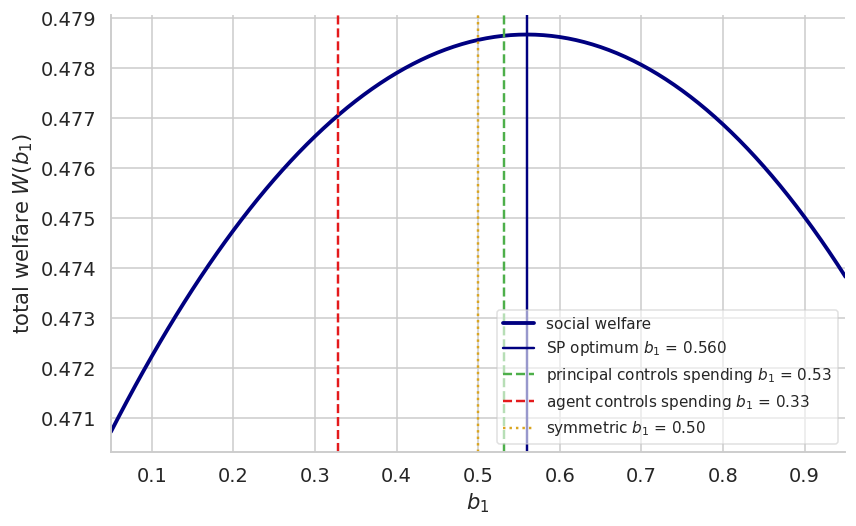

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(B_SP, W_arr, color=COLORS['sp'], lw=2.5, label='social welfare')

vlines = [
    (b_SP, '-',  COLORS['sp'], f'SP optimum $b_1$ = {b_SP:.3f}'),
    (b_P,  '--', COLORS['p'],  f'principal controls spending $b_1$ = {b_P:.2f}'),
    (b_A,  '--', COLORS['a'],  f'agent controls spending $b_1$ = {b_A:.2f}'),
    (0.50, ':',  'goldenrod',  'symmetric $b_1$ = 0.50'),
]
for xv, ls, col, lbl in vlines:
    ax.axvline(xv, color=col, ls=ls, lw=1.6, label=lbl)

ax.set(xlabel='$b_1$', ylabel='total welfare $W(b_1)$', xlim=(B_SP[0], B_SP[-1]))
ax.legend(fontsize=10, framealpha=0.6, loc='best')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
plt.tight_layout(); plt.show()

---
# Summary (at $n = \tfrac12$)

In [20]:
summary = pd.DataFrame({
    'first-best':         [b_FB,  e_FB,   e_FB,   e_FB,   pi_FB,  0.0,        pi_FB],
    'agent controls spending':     [b_A,   e1_A,   e21_A,  e20_A,  pi_A,   A_A,        W_A],
    'principal controls spending': [b_P,   e1_P,   e21_P,  e20_P,  pi_P,   A_P,        W_P],
    'social planner':     [b_SP,  sp['e1'], sp['e21'], sp['e20'], sp['profit'], W_SP - sp['profit'], W_SP],
}, index=['b_1', 'e_1', 'e_2(1)', 'e_2(0)', 'profit', 'rent', 'welfare']).round(4)

print(summary.to_string())

         first-best  agent controls spending  principal controls spending  social planner
b_1          0.5000                   0.3284                       0.5320          0.5600
e_1          0.6124                   0.3359                       0.3436          0.3465
e_2(1)       0.6124                   0.5930                       0.6058          0.6000
e_2(0)       0.6124                   0.2490                       0.2401          0.2371
profit       0.6124                   0.3335                       0.3357          0.3357
rent         0.0000                   0.1459                       0.1430          0.1430
welfare      0.6124                   0.4794                       0.4786          0.4787


---
# 6 Extensions

## §6.1 Robustness in $n$: the value of money

Sweep $n \in [0.1, 0.95]$ and re-solve all three regimes at each value, recording $b_1$, profit, and total welfare $W = \Pi + U$.

In [21]:
n_save = n
n_values = np.linspace(0.10, 0.95, 18)
B_SP_GRID = np.linspace(0.05, 0.95, 91)
results_n = []

def _total_welfare(e1, e21, e20, b1, n_val):
    return (e1 + e1 * e21 + (1 - e1) * e20
            - e1**2 / (1 + b1)**n_val
            - e1 * e21**2 / (2 - b1)**n_val
            - (1 - e1) * e20**2 / (2 - b1)**n_val)

for n_val in n_values:
    globals()['n'] = float(n_val)

    # Principal controls spending
    e1g  = np.empty_like(B_GRID)
    e20g = np.empty_like(B_GRID)
    e21g = np.empty_like(B_GRID)
    for i, b in enumerate(B_GRID):
        try:
            e1g[i], e20g[i], e21g[i] = solve_principal_at_b(b)
        except Exception:
            e1g[i] = e20g[i] = e21g[i] = np.nan
    pig = profit_principal(e1g, e20g, e21g, B_GRID)
    pig = np.where(np.isfinite(pig), pig, -np.inf)
    idx_P = int(np.argmax(pig))
    b1P_n, piP_n = B_GRID[idx_P], pig[idx_P]
    e1P_n, e21P_n, e20P_n = e1g[idx_P], e21g[idx_P], e20g[idx_P]
    WP_n = _total_welfare(e1P_n, e21P_n, e20P_n, b1P_n, n_val)

    # Agent controls spending
    GRID_C = np.linspace(0.05, 0.95, 9)
    best_pi, best_start = -np.inf, (0.4, 0.9, 0.4)
    for t1 in GRID_C:
        for t21 in GRID_C:
            for t20 in GRID_C:
                pi, _ = profit_agent_controls(t1, t21, t20)
                if np.isfinite(pi) and pi > best_pi:
                    best_pi, best_start = pi, (t1, t21, t20)
    def _neg_pa(x):
        pi, _ = profit_agent_controls(*x)
        return -pi if np.isfinite(pi) else 1e6
    res = minimize(_neg_pa, best_start, method='L-BFGS-B',
                   bounds=[(1e-3, 1-1e-3)]*3, options={'ftol': 1e-10})
    piA_n, vals = profit_agent_controls(*res.x)
    if vals is not None and np.isfinite(piA_n):
        b1A_n, e1A_n, e21A_n, e20A_n = vals
    else:
        b1A_n = e1A_n = e21A_n = e20A_n = np.nan
        piA_n = np.nan
    WA_n = _total_welfare(e1A_n, e21A_n, e20A_n, b1A_n, n_val)

    # Social planner
    SP_W = np.array([
        (solve_principal_transfers_at_b(b) or {}).get('welfare', np.nan)
        for b in B_SP_GRID
    ])
    idx_SP = int(np.nanargmax(SP_W))
    b1SP_n, WSP_n = B_SP_GRID[idx_SP], SP_W[idx_SP]

    delta_pct = 100 * (piP_n - piA_n) / piP_n if piP_n > 0 else np.nan
    results_n.append((n_val, b1P_n, b1A_n, b1SP_n,
                      e1P_n, e1A_n, e21P_n, e21A_n, e20P_n, e20A_n,
                      piP_n, piA_n, delta_pct, WP_n, WA_n, WSP_n))

globals()['n'] = n_save

_arr = np.array(results_n)
n_arr     = _arr[:,  0]
b1P_arr   = _arr[:,  1]
b1A_arr   = _arr[:,  2]
b1SP_arr  = _arr[:,  3]
piP_arr   = _arr[:, 10]
piA_arr   = _arr[:, 11]
delta_arr = _arr[:, 12]
WP_arr    = _arr[:, 13]
WA_arr    = _arr[:, 14]
WSP_arr   = _arr[:, 15]

assert np.all((b1A_arr < b1P_arr) & (b1P_arr < b1SP_arr))

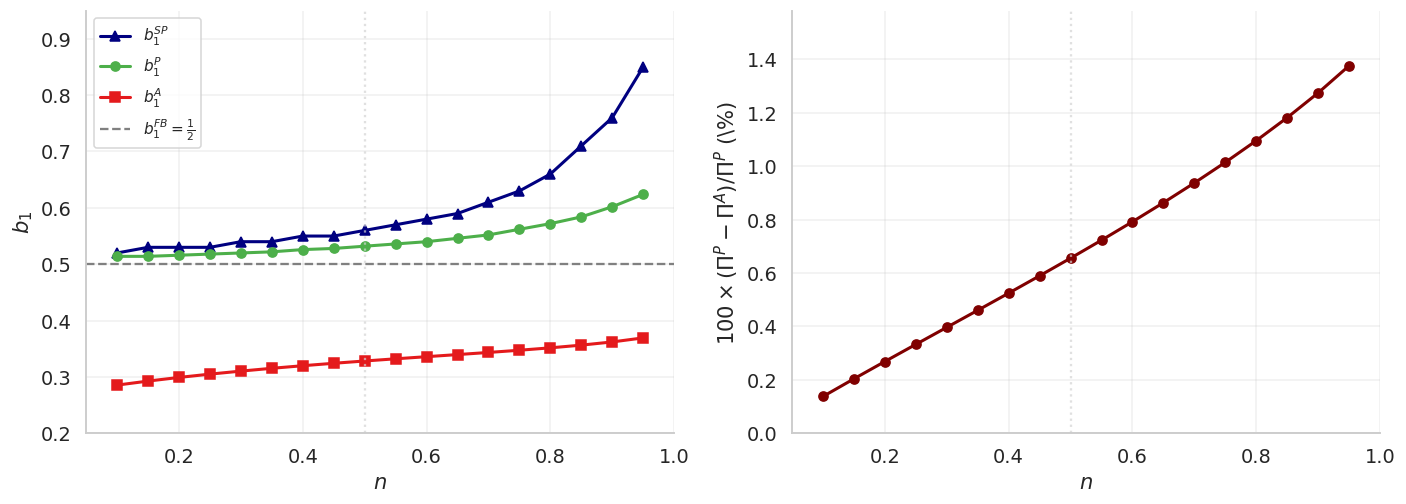

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ax1.plot(n_arr, b1SP_arr, '^-', color=COLORS['sp'], lw=2, label=r'$b_1^{SP}$')
ax1.plot(n_arr, b1P_arr,  'o-', color=COLORS['p'],  lw=2, label=r'$b_1^P$')
ax1.plot(n_arr, b1A_arr,  's-', color=COLORS['a'],  lw=2, label=r'$b_1^A$')
ax1.axhline(0.5, color='gray', linestyle='--', lw=1.5, label=r'$b_1^{FB}=\frac{1}{2}$')
ax1.axvline(0.5, color='lightgray', linestyle=':', alpha=0.7)
ax1.set_xlabel(r'$n$')
ax1.set_ylabel(r'$b_1$')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.05, 1.0)
ax1.set_ylim(0.2, 0.95)

ax2.plot(n_arr, delta_arr, 'o-', color='maroon', lw=2)
ax2.axvline(0.5, color='lightgray', linestyle=':', alpha=0.7)
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'$100 \times (\Pi^P - \Pi^A)/\Pi^P$ (\%)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.05, 1.0)
ax2.set_ylim(0, max(delta_arr) * 1.15)

plt.tight_layout()
plt.show()

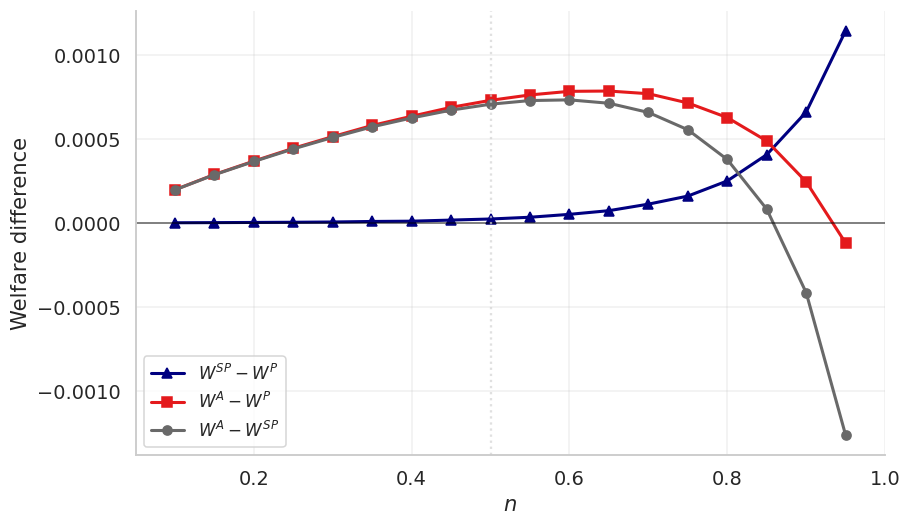

In [23]:
fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(n_arr, WSP_arr - WP_arr, '^-', color=COLORS['sp'], lw=2, label=r'$W^{SP} - W^P$')
ax.plot(n_arr, WA_arr  - WP_arr, 's-', color=COLORS['a'],  lw=2, label=r'$W^A - W^P$')
ax.plot(n_arr, WA_arr  - WSP_arr,'o-', color='dimgray',    lw=2, label=r'$W^A - W^{SP}$')
ax.axhline(0, color='black', lw=1, alpha=0.6)
ax.axvline(0.5, color='lightgray', linestyle=':', alpha=0.7)
ax.set_xlabel(r'$n$')
ax.set_ylabel(r'Welfare difference')
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.05, 1.0)
plt.tight_layout()
plt.show()

## §6.2 Discounting

$$\Pi_\delta = e_1\!\left(1 + \delta\!\left(e_2(1) - \frac{e_2(1)^2}{(2-b_1)^n}\right)\right) + \delta\, e_2(0) - 2\delta\, \frac{e_2(0)^2}{(2-b_1)^n} - \frac{2\, e_1^2}{(1+b_1)^n} - e_1\, \delta\!\left(e_2(0) - \frac{e_2(0)^2}{(2-b_1)^n}\right),$$
with the effort FOCs modified accordingly. For each $\delta$ on a grid, solve the effort system at every $b_1$ and take the profit maximizer. The threshold $\delta^*$ is the smallest $\delta$ at which that maximizer falls below one.

In [24]:
def solve_principal_at_b_delta(b1, delta):
    b1  = min(b1, 1 - 1e-9)
    e21 = (2 - b1)**n / 2
    def focs(p):
        x, y = p
        return [
            (1 + delta*(2-b1)**n/4 - 4*x/(1+b1)**n
             - delta*y + delta*y**2/(2-b1)**n),
            1 - 4*y/(2-b1)**n - x + 2*x*y/(2-b1)**n,
        ]
    e1, e20 = fsolve(focs, [0.30, 0.20], xtol=1e-12)
    return e1, e20, e21

def profit_principal_delta(e1, e20, e21, b1, delta):
    return (e1 * (1 + delta * (e21 - e21**2 / (2 - b1)**n))
            + delta * e20 - 2 * delta * e20**2 / (2 - b1)**n
            - 2 * e1**2 / (1 + b1)**n
            - e1 * delta * (e20 - e20**2 / (2 - b1)**n))

DELTAS = np.linspace(0, 1, 101)
B_DISC = np.linspace(0, 1, 101)

e1_d, e20_d, e21_d, b1_d = (np.empty_like(DELTAS) for _ in range(4))
for k, delta in enumerate(DELTAS):
    profs = np.array([profit_principal_delta(*solve_principal_at_b_delta(b, delta), b, delta)
                      for b in B_DISC])
    j     = int(np.argmax(profs))
    b_opt = B_DISC[j]
    e1_d[k], e20_d[k], e21_d[k] = solve_principal_at_b_delta(b_opt, delta)
    b1_d[k] = b_opt

def b1_opt_at_delta(delta):
    profs = np.array([profit_principal_delta(*solve_principal_at_b_delta(b, delta), b, delta)
                      for b in B_DISC])
    return B_DISC[int(np.argmax(profs))]

# bracket from the sweep, then bisect for the threshold itself
mask   = b1_d < 0.999
k      = int(np.argmax(mask))
lo, hi = DELTAS[k-1], DELTAS[k]
for _ in range(30):
    mid = 0.5 * (lo + hi)
    if b1_opt_at_delta(mid) < 0.999:
        hi = mid
    else:
        lo = mid
crit_delta = 0.5 * (lo + hi)
print(f'Critical delta:  delta* = {crit_delta:.4f}')

Critical delta:  delta* = 0.6501


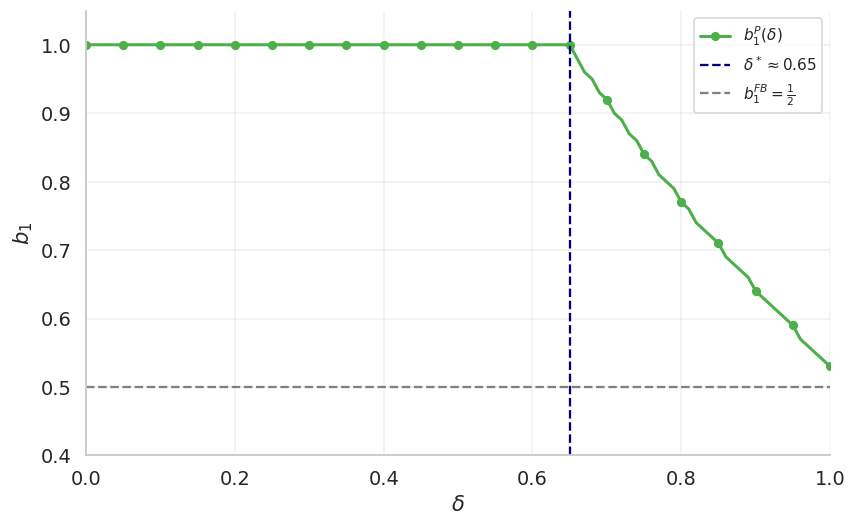

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(DELTAS, b1_d, 'o-', color=COLORS['p'], lw=2, markevery=5, ms=5,
        label=r'$b_1^P(\delta)$')
ax.axvline(crit_delta, color='navy', ls='--', lw=1.5,
           label=fr'$\delta^*\approx {crit_delta:.2f}$')
ax.axhline(0.5, color='gray', ls='--', lw=1.5, label=r'$b_1^{FB}=\frac{1}{2}$')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel(r'$b_1$')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0.4, 1.05)
plt.tight_layout(); plt.show()